# Atividade - Tabela 13: meio de transporte das mulheres ocupadas (2022)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Tabela_13_Meio_de_transporte.xlsx", sheet_name="Exemplo gráfico Brasil", header=1)
df.columns = ["Meio de Transporte", "Branca", "Preta ou Parda", "Indígena"]
df

                Meio de Transporte  Branca  Preta ou Parda  Indígena
0                             A pé    19.4            24.8      37.5
1                        Bicicleta     3.2             5.2       5.9
2          Motocicleta ou Mototaxi     9.9            14.2      15.4
3  Automóvel, taxi ou assemelhados    41.8            20.6      15.2
4              Transporte coletivo    25.2            34.6      22.4
5                           Outros     0.5             0.6       3.6

## Gráficos de pizza

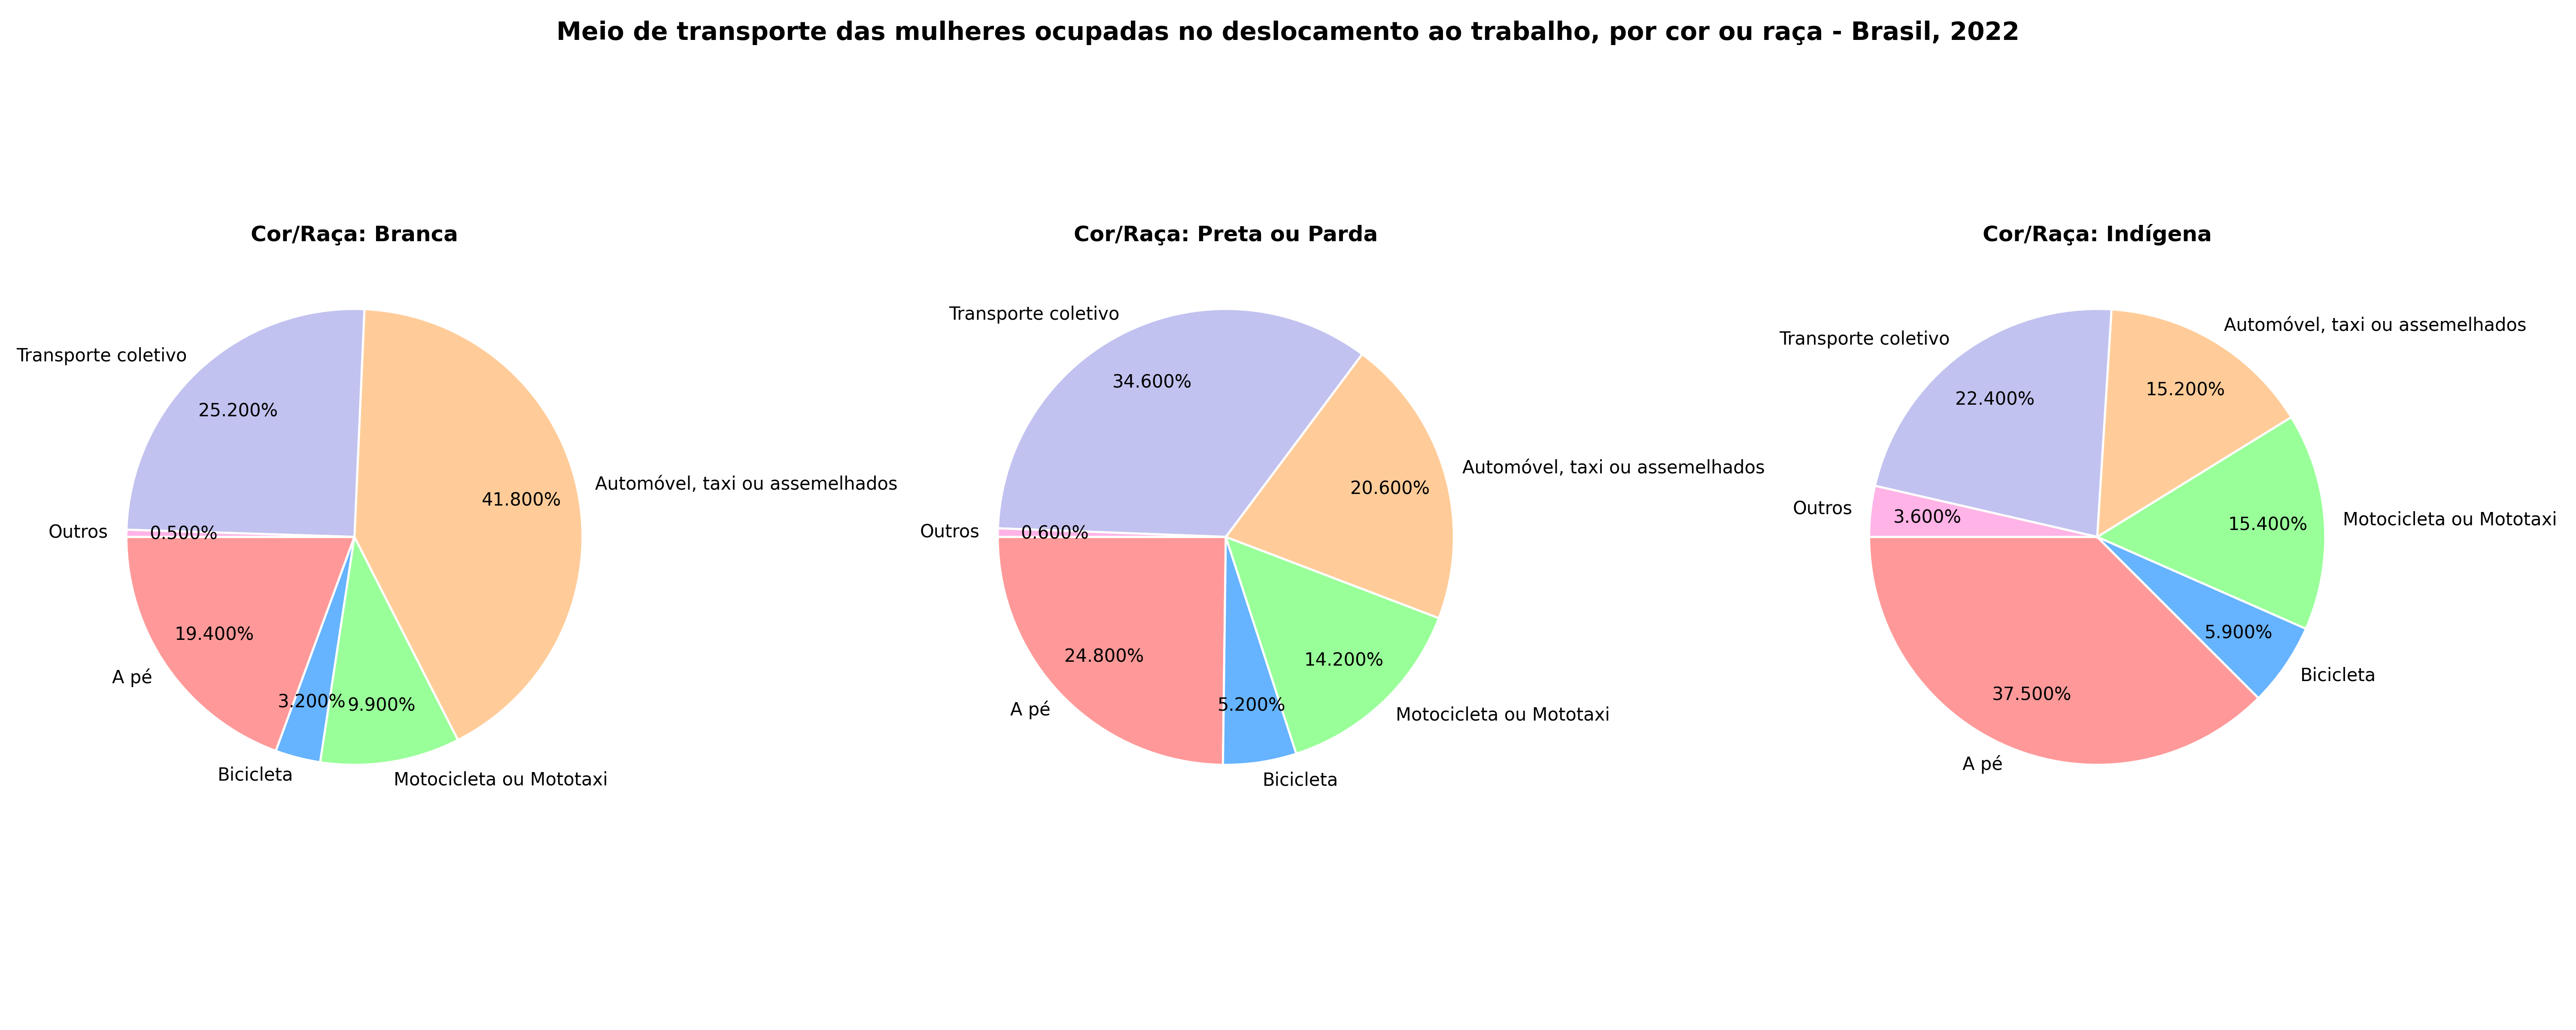

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        pctdistance=0.75,
        labeldistance=1.08,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Meio de transporte das mulheres ocupadas no deslocamento ao trabalho, por cor ou raça - Brasil, 2022',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

## Análise dos gráficos

Os percentuais mostram como as mulheres ocupadas de cada grupo de cor ou raça se distribuem entre os meios de transporte. Por isso as diferenças abaixo são em pontos percentuais (p.p.), e não em número de mulheres.

**A pé** (brancas 19,4%, pretas ou pardas 24,8%, indígenas 37,5%)

- Mulheres brancas - mulheres pretas ou pardas: 5,4 p.p. (pretas ou pardas usam mais)
- Mulheres brancas - mulheres indígenas: 18,1 p.p. (indígenas usam mais)
- Mulheres pretas ou pardas - mulheres indígenas: 12,7 p.p. (indígenas usam mais)

**Bicicleta** (brancas 3,2%, pretas ou pardas 5,2%, indígenas 5,9%)

- Mulheres brancas - mulheres pretas ou pardas: 2,0 p.p. (pretas ou pardas usam mais)
- Mulheres brancas - mulheres indígenas: 2,7 p.p. (indígenas usam mais)
- Mulheres pretas ou pardas - mulheres indígenas: 0,7 p.p. (indígenas usam mais)

**Motocicleta ou Mototaxi** (brancas 9,9%, pretas ou pardas 14,2%, indígenas 15,4%)

- Mulheres brancas - mulheres pretas ou pardas: 4,3 p.p. (pretas ou pardas usam mais)
- Mulheres brancas - mulheres indígenas: 5,5 p.p. (indígenas usam mais)
- Mulheres pretas ou pardas - mulheres indígenas: 1,2 p.p. (indígenas usam mais)

**Automóvel, taxi ou assemelhados** (brancas 41,8%, pretas ou pardas 20,6%, indígenas 15,2%)

- Mulheres brancas - mulheres pretas ou pardas: 21,2 p.p. (brancas usam mais)
- Mulheres brancas - mulheres indígenas: 26,6 p.p. (brancas usam mais)
- Mulheres pretas ou pardas - mulheres indígenas: 5,4 p.p. (pretas ou pardas usam mais)

**Transporte coletivo** (brancas 25,2%, pretas ou pardas 34,6%, indígenas 22,4%)

- Mulheres brancas - mulheres pretas ou pardas: 9,4 p.p. (pretas ou pardas usam mais)
- Mulheres brancas - mulheres indígenas: 2,8 p.p. (brancas usam mais)
- Mulheres pretas ou pardas - mulheres indígenas: 12,2 p.p. (pretas ou pardas usam mais)

**Outros** (brancas 0,5%, pretas ou pardas 0,6%, indígenas 3,6%)

- Mulheres brancas - mulheres pretas ou pardas: 0,1 p.p. (pretas ou pardas usam mais)
- Mulheres brancas - mulheres indígenas: 3,1 p.p. (indígenas usam mais)
- Mulheres pretas ou pardas - mulheres indígenas: 3,0 p.p. (indígenas usam mais)

**Resumo**

- O automóvel é onde a diferença mais pesa: 41,8% das mulheres brancas usam carro, contra 20,6% das pretas ou pardas e 15,2% das indígenas.
- O transporte coletivo é o principal meio das mulheres pretas ou pardas (34,6%), acima das brancas (25,2%) e das indígenas (22,4%).
- Andar a pé é o principal meio das mulheres indígenas (37,5%), bem acima das pretas ou pardas (24,8%) e das brancas (19,4%).
- Bicicleta e motocicleta têm diferenças menores, de até 5,5 p.p., mas ficam mais presentes entre pretas ou pardas e indígenas do que entre brancas.
- Em "Outros" as mulheres indígenas chegam a 3,6%, enquanto brancas e pretas ou pardas ficam perto de 0,5%.

# Parte 2

In [4]:
dados = pd.read_excel("Tabela_13_Meio_de_transporte.xlsx", sheet_name="BR GR UF MU", header=None, skiprows=3)

modos = ["a_pe", "bicicleta", "moto", "carro", "coletivo", "outros"]
grupos = ["branca", "preta_parda", "indigena"]
dados.columns = ["local"] + [f"{g}_{m}" for g in grupos for m in modos]

for col in dados.columns[1:]:
    dados[col] = pd.to_numeric(dados[col], errors="coerce")

dados.head()

      local  branca_a_pe  ...  indigena_coletivo  indigena_outros
0    Brasil         19.4  ...               22.4              3.6
1     Norte         15.2  ...                9.1             10.6
2  Nordeste         24.9  ...               20.6              0.7
3   Sudeste         18.5  ...               39.4              0.6
4       Sul         20.8  ...               36.4              1.0

[5 rows x 19 columns]

## Só os estados

In [5]:
fora = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-oeste"]
estados = dados[~dados["local"].isin(fora) & ~dados["local"].str.contains(r"\(")].copy()
print(len(estados))
estados

27


                  local  branca_a_pe  ...  indigena_coletivo  indigena_outros
6              Rondônia         11.7  ...                1.9              0.6
7                  Acre         14.8  ...                6.8              6.7
8              Amazonas         13.9  ...                8.7             14.9
9               Roraima         11.6  ...                7.3              1.4
10                 Pará         17.5  ...               16.9              4.7
11                Amapá         14.1  ...               10.3             24.0
12            Tocantins         15.9  ...                8.7              1.4
13             Maranhão         21.0  ...               15.8              NaN
14                Piauí         18.2  ...               21.2              NaN
15                Ceará         20.5  ...               23.7              1.1
16  Rio Grande do Norte         20.9  ...               24.2              1.3
17              Paraíba         23.7  ...               19.3    

## Qual estado tem mais e qual tem menos mulheres usando transporte coletivo?

Como a tabela traz percentuais, "mais mulheres" quer dizer maior percentual. Para o "em geral" usei a média dos três grupos de cor ou raça.

In [6]:
coletivo = estados.melt(
    id_vars="local",
    value_vars=["branca_coletivo", "preta_parda_coletivo", "indigena_coletivo"],
    var_name="grupo",
    value_name="coletivo",
)

media_coletivo = coletivo.groupby("local")["coletivo"].mean().sort_values(ascending=False)

print("Mais mulheres no transporte coletivo:", media_coletivo.idxmax(), round(media_coletivo.max(), 2))
print("Menos mulheres no transporte coletivo:", media_coletivo.idxmin(), round(media_coletivo.min(), 2))
print()
print(media_coletivo.head(5).round(2))
print()
print(media_coletivo.tail(5).round(2))

Mais mulheres no transporte coletivo: Rio de Janeiro 52.23
Menos mulheres no transporte coletivo: Rondônia 4.33

local
Rio de Janeiro       52.23
Distrito Federal     46.00
São Paulo            40.73
Rio Grande do Sul    36.10
Sergipe              33.40
Name: coletivo, dtype: float64

local
Mato Grosso    9.80
Acre           9.20
Tocantins      8.60
Roraima        8.13
Rondônia       4.33
Name: coletivo, dtype: float64


## Qual cidade tem mais mulheres andando de bicicleta?

In [7]:
municipios = dados[dados["local"].str.contains(r"\(")].copy()
print(len(municipios))

bicicleta = municipios.melt(
    id_vars="local",
    value_vars=["branca_bicicleta", "preta_parda_bicicleta", "indigena_bicicleta"],
    var_name="grupo",
    value_name="bicicleta",
)

media_bicicleta = bicicleta.groupby("local")["bicicleta"].mean().sort_values(ascending=False)

print("Cidade com mais mulheres de bicicleta:", media_bicicleta.idxmax(), round(media_bicicleta.max(), 2))
print()
print(media_bicicleta.head(5).round(2))

5570
Cidade com mais mulheres de bicicleta: Tuiuti (SP) 100.0

local
Tuiuti (SP)                100.00
Afuá (PA)                   72.05
Novo Santo Antônio (MT)     68.90
Lagoa Grande (MG)           67.87
Britânia (GO)               64.47
Name: bicicleta, dtype: float64


## Qual cidade tem mais mulheres usando carro?

In [8]:
carro = municipios.melt(
    id_vars="local",
    value_vars=["branca_carro", "preta_parda_carro", "indigena_carro"],
    var_name="grupo",
    value_name="carro",
)

media_carro = carro.groupby("local")["carro"].mean().sort_values(ascending=False)

print("Cidade com mais mulheres de carro:", media_carro.idxmax(), round(media_carro.max(), 2))
print()
print(media_carro.head(5).round(2))

Cidade com mais mulheres de carro: Bom Jesus do Oeste (SC) 86.05

local
Bom Jesus do Oeste (SC)    86.05
Bom Jesus (SC)             74.57
Tupanci do Sul (RS)        74.55
Valinhos (SP)              71.43
Piratininga (SP)           71.40
Name: carro, dtype: float64


**Cuidado ao ler as cidades:** a tabela só traz percentuais, sem o número de mulheres. Em cidade pequena, um grupo com pouquíssimas mulheres pode aparecer com 100% em um meio de transporte, e isso puxa a média para cima. Foi o que aconteceu em Tuiuti (SP), que só tem dado do grupo indígena para bicicleta, e em Bom Jesus do Oeste (SC), com 100% de carro entre pretas ou pardas. Por isso vale olhar também o restante do top 5.